# 03. Models Training and Evaluation:
    • Model0/ #(ScratchResNet)    
    • Model1/ #(ResNet18)    
    • Model2/ #(ResNet18 w/ Temporal Vector)



In [1]:
# Step 1. Setup and Imports
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

import subprocess

def get_repo_root():
    return subprocess.check_output(['git', 'rev-parse', '--show-toplevel']).decode('utf-8').strip()
repo_root = get_repo_root()
print(repo_root)

src_path = os.path.join(repo_root, 'src')
# Add src_path to sys.path if not already present
if src_path not in sys.path:
    sys.path.insert(0, repo_root)
    sys.path.insert(0, src_path)
#sys.path.append(str(repo_root))

# Set random seeds for reproducibility
RANDOM_SEED = 42


import logging
# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(filename)s:%(lineno)d - %(funcName)s() - %(message)s"
)
logger = logging.getLogger(__name__)

def set_seed(seed: int):
    # Python built‐ins
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch CPU & CUDA
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # PyTorch MPS (Apple GPU)
    if torch.backends.mps.is_available():
        try:
            # New in PyTorch 2+: seeds MPS generator
            torch.mps.manual_seed(seed)
        except AttributeError:
            # Fallback pre–PyTorch 2.0: no direct MPS seeding, CPU generator only
            torch.manual_seed(seed)

    # Enforce deterministic algorithms where possible
    torch.use_deterministic_algorithms(True)
    # For CUDA backends only:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# Example usage
set_seed(RANDOM_SEED)
print(f"Project root: {repo_root}")


/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan
Project root: /Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan


In [2]:
# Step 2. Import Required Classes 

import importlib
import wildscan_ml_system
import custom_models
import trainer


importlib.reload(wildscan_ml_system)
importlib.reload(custom_models)
importlib.reload(trainer)

from custom_models import AnimalTemporalClassifier, AnimalClassifier, ScratchResNet
from trainer import WildScanTrainer as Trainer
from wildscan_ml_system import PretrainingPipeline, SystemConfig  



In [3]:
# Step 3: Create SystemConfig for PretrainingPipeline Only
def create_notebook_config():
    
    """Create configuration optimized for notebook pretraining"""
    def get_device():
        if torch.cuda.is_available():
            return "cuda"
        elif torch.backends.mps.is_available():
            return "mps"
        else:
            return "cpu"

    config = SystemConfig(
        # Project settings
        project_name="notebook_pretraining",
        experiment_name="pretraining_experiment",

        device = get_device(),
        # Data paths
        train_data_path="./data_split/train-meta.csv", #benchmark eccv18 1st year
        val_data_path="./data_split/val-meta.csv", #benchmark eccv18 1st year (calibration data)
        test_data_path="./data_split/test-meta.csv",#benchmark eccv18 1st year (in distribution test set)
        ood_data_path="./data_split/year1/val-meta.csv", # out of distribution data for year 1 (outside locations)
        

        # Preprocessed images path
        preprocessed_images_path= "../dataset/cct_resized/",

        # label mapping path
        label2idx_path = "./data_split/label_mapping.json",

        # models to use
        models_to_use = [0],
        
        # Training settings (notebook-friendly)
        batch_size=32,
        learning_rate=1e-4,
        weight_decay=0,
        patience = 0,
        epochs=10,  # Reduced for notebook

        # criterion
        criterion=nn.CrossEntropyLoss(),
        
        # Pipeline settings - ONLY PRETRAINING
        enable_pretraining_pipeline=True,
        enable_production_pipeline=False,  # Not needed

        # model training output dir
        training_output_dir="./pretrained_models",
        
        # Logging
        output_dir="./notebook_outputs",
        log_level="INFO",
        #console_logging=False,
        #include_full_file_paths=False  # Cleaner for notebook
        
    )
    
    
    
    return config

# Create configuration
config = create_notebook_config()
print("📝 Configuration created for notebook pretraining")
print(f"   - Device: {config.device}")
print(f"   - Output: {config.output_dir}")
print(f"   - Epochs: {config.epochs}")

📝 Configuration created for notebook pretraining
   - Device: mps
   - Output: ./notebook_outputs
   - Epochs: 10


In [4]:
# Step 4: Initialize PretrainingPipeline Directly
# Create the pipeline instance WITHOUT MasterMLSystem
pretraining_pipeline = []
pretraining_pipeline = PretrainingPipeline(config)

print("🔬 PretrainingPipeline initialized successfully!")
#print(f"   - Default optimizer: {pretraining_pipeline.default_trainer_config.optimizer_class.__name__}")
#print(f"   - Default epochs: {pretraining_pipeline.default_trainer_config.epochs}")

🔬 PretrainingPipeline initialized successfully!


2025-08-09 08:23:56,593 - INFO - wildscan_ml_system.py:483 - run_pipeline() - 🔬 Starting Pretraining Pipeline...
2025-08-09 08:23:56,594 - INFO - wildscan_ml_system.py:229 - setup_datasets() - Setting up datasets for pretraining...
2025-08-09 08:23:56,595 - DEBUG - custom_datasets.py:56 - __init__() - input local csv: ./data_split/train-meta.csv
2025-08-09 08:23:56,631 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (9088, 16)
2025-08-09 08:23:56,632 - DEBUG - custom_datasets.py:84 - __init__() - no need to initialize s3fs since using local directory for dataset
2025-08-09 08:23:56,632 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-09 08:23:56,633 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 9088 samples.
2025-08-09 08:23:56,634 - DEBUG - custom_datasets.py:56 - __init__() - input local csv: ./data_split/val-meta.csv
2025-08-09 08:23:56,641 - INFO - custom_datasets.py:70 - __init__() - Dataset 

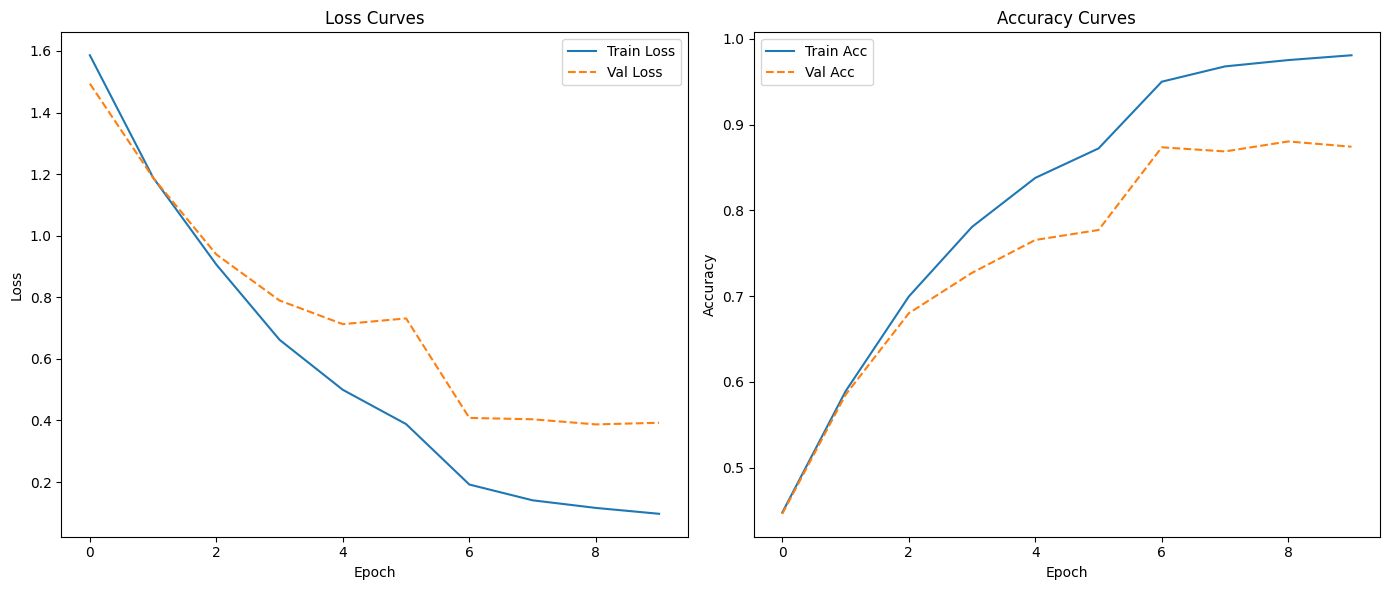

2025-08-09 08:34:42,006 - INFO - wildscan_ml_system.py:343 - train_models() - Model No 0 : ScratchResNet loaded with best weights.
2025-08-09 08:34:42,010 - INFO - wildscan_ml_system.py:348 - evaluate_models() - Evaluating models...
2025-08-09 08:34:42,011 - INFO - wildscan_ml_system.py:354 - evaluate_models() - Found 1 model(s) to evaluate.
2025-08-09 08:34:42,011 - INFO - wildscan_ml_system.py:361 - evaluate_models() - Evaluating Model No 0 : ScratchResNet...
2025-08-09 08:34:42,013 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 08:35:01,046 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]



=== MODEL ScratchResNet ===
Accuracy: 0.8309682804674458
F1-score (macro): 0.6959744084074594
ROC-AUC: 0.9749067299543833
Classification Report:
               precision    recall  f1-score   support

         car       1.00      1.00      1.00       648
      coyote       0.79      0.85      0.82       526
         dog       0.66      0.80      0.72       299
      bobcat       0.81      0.78      0.80       445
      rabbit       0.79      0.90      0.84      1004
        deer       1.00      0.54      0.70        13
     opossum       0.95      0.89      0.92      2404
     raccoon       0.72      0.86      0.79       507
    squirrel       0.59      0.56      0.58       329
         cat       0.75      0.71      0.73       666
        bird       0.58      0.23      0.33       227
       skunk       0.73      0.83      0.77        58
      rodent       0.68      0.85      0.75        61
         fox       0.00      0.00      0.00         1

    accuracy                           0.

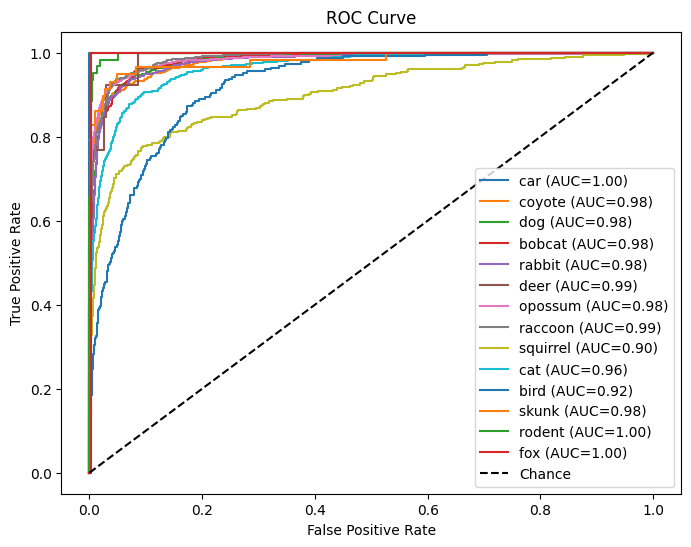

2025-08-09 08:35:01,286 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 08:35:29,943 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  6  7  8  9 10 11 12]
2025-08-09 08:35:29,944 - WARNING - evaluator.py:99 - evaluate() - Mismatch between present classes in evaluation set and model label mapping. Present classes: [ 0  1  2  3  4  6  7  8  9 10 11 12], Model classes: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])



=== MODEL ScratchResNet ===
Accuracy: 0.6427512050426399
F1-score (macro): 0.466326815437673
ROC-AUC: not available
Classification Report:
               precision    recall  f1-score   support

         car       1.00      1.00      1.00       747
      coyote       0.41      0.52      0.46      1090
         dog       0.18      0.28      0.22       234
      bobcat       0.78      0.54      0.64      1983
      rabbit       0.50      0.60      0.55       478
        deer       0.00      0.00      0.00         0
     opossum       0.81      0.84      0.83      2438
     raccoon       0.84      0.55      0.67      2647
    squirrel       0.36      0.73      0.48       430
         cat       0.22      0.49      0.31       395
        bird       0.12      0.13      0.13        82
       skunk       0.88      0.61      0.72       249
      rodent       0.04      0.20      0.06        15
         fox       0.00      0.00      0.00         0

    accuracy                           0.64    

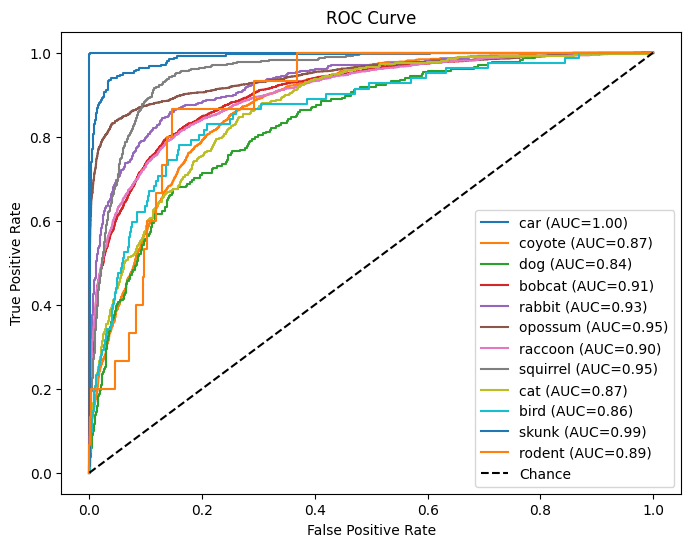

2025-08-09 08:35:30,123 - INFO - wildscan_ml_system.py:389 - evaluate_confidences() - Evaluating Confidence Metrics for Model No 0 : ScratchResNet...
2025-08-09 08:35:30,123 - INFO - wildscan_ml_system.py:390 - evaluate_confidences() - Setup calibration data from validation set for this model...
2025-08-09 08:35:30,125 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 08:35:33,963 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps


Dataset  7188 test samples, 14 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.038038,0.029833,21.569152
1,Overconfidence Error,0.036264,0.010807,0.000000
2,Brier Score,0.101832,0.103096,0.000000


2025-08-09 08:35:53,650 - DEBUG - font_manager.py:1379 - _findfont_cached() - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=14.0.
2025-08-09 08:35:53,651 - DEBUG - font_manager.py:1391 - _findfont_cached() - findfont: score(FontEntry(fname='/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2025-08-09 08:35:53,651 - DEBUG - font_manager.py:1391 - _findfont_cached() - findfont: score(FontEntry(fname='/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2025-08-09 08:35:53,652 - DEBUG - font_manager.py:1391 - _findfont_cached() - findfont: score(FontEntry(fname='/opt/miniconda3/envs/pytorch

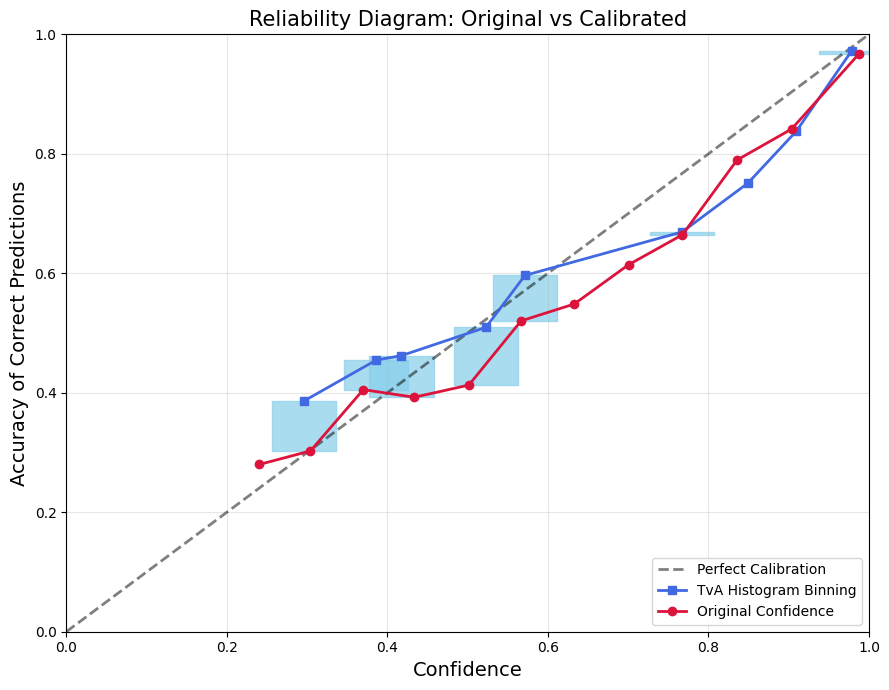

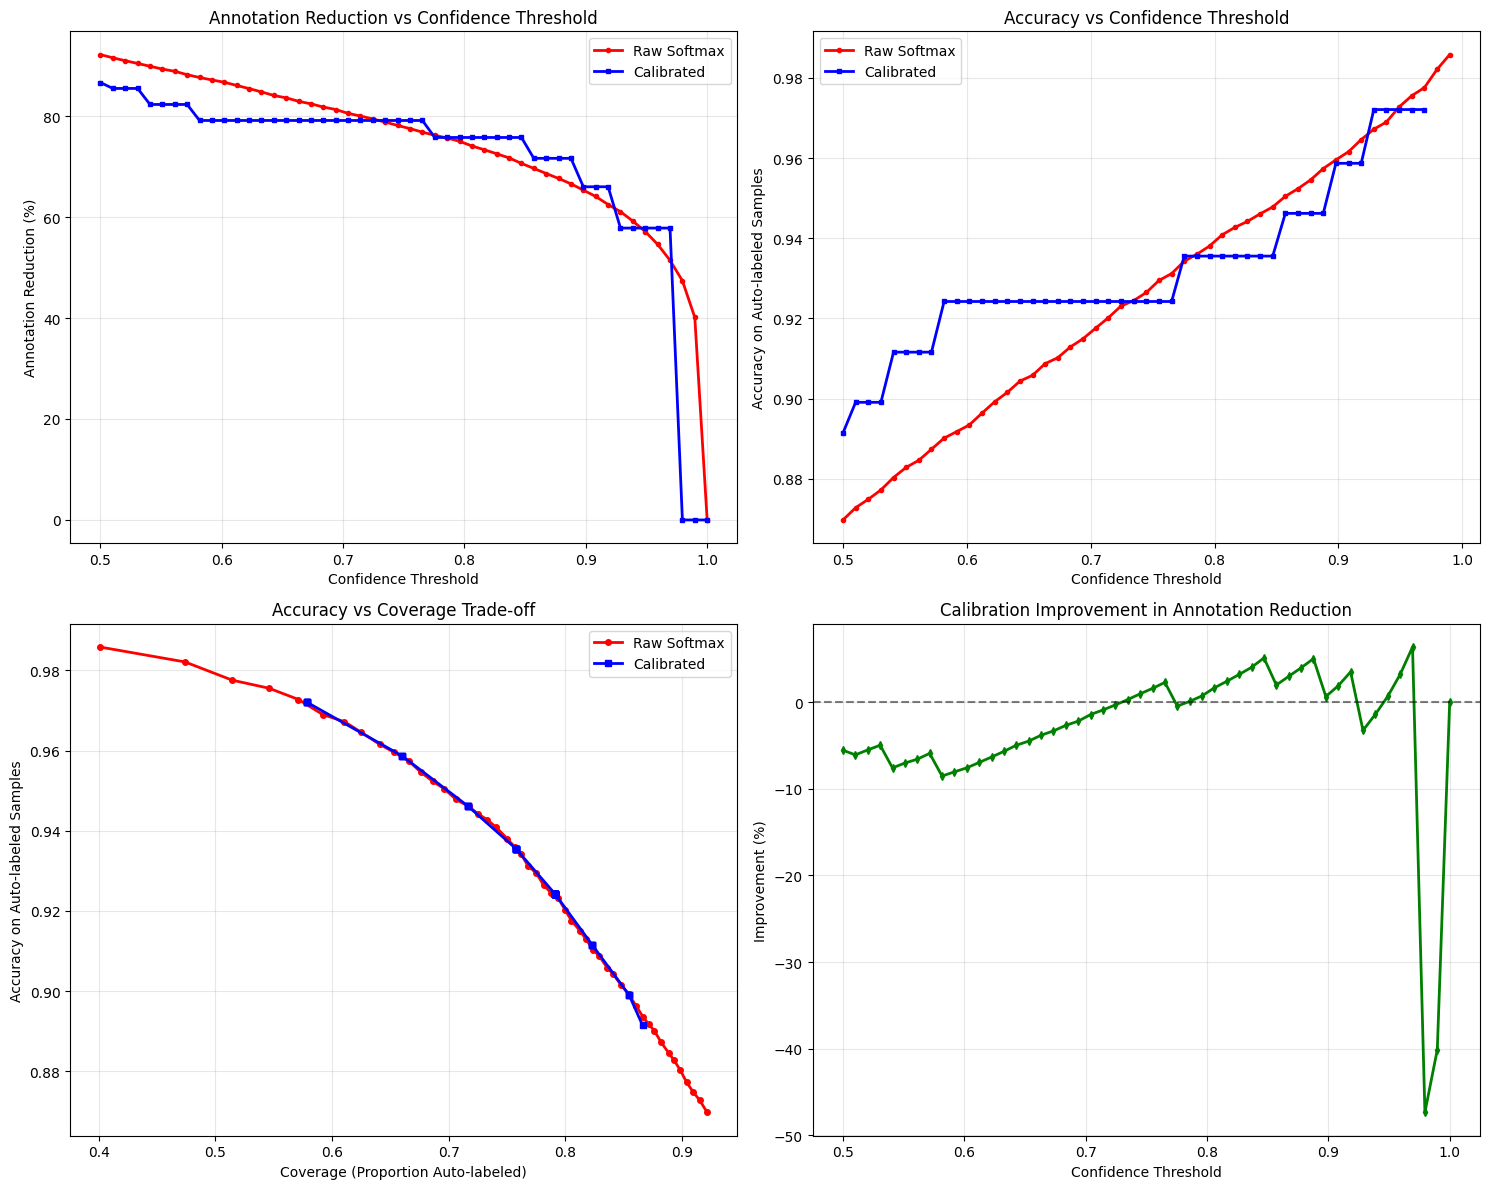

2025-08-09 08:35:54,886 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 08:36:23,025 - INFO - wildscan_ml_system.py:442 - evaluate_confidences() - Evaluating confidence metrics on out-of-distribution test set...


Dataset  10788 test samples, 12 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.160788,0.131912,17.958989
1,Overconfidence Error,0.160788,0.128091,0.000000
2,Brier Score,0.204692,0.201100,0.000000


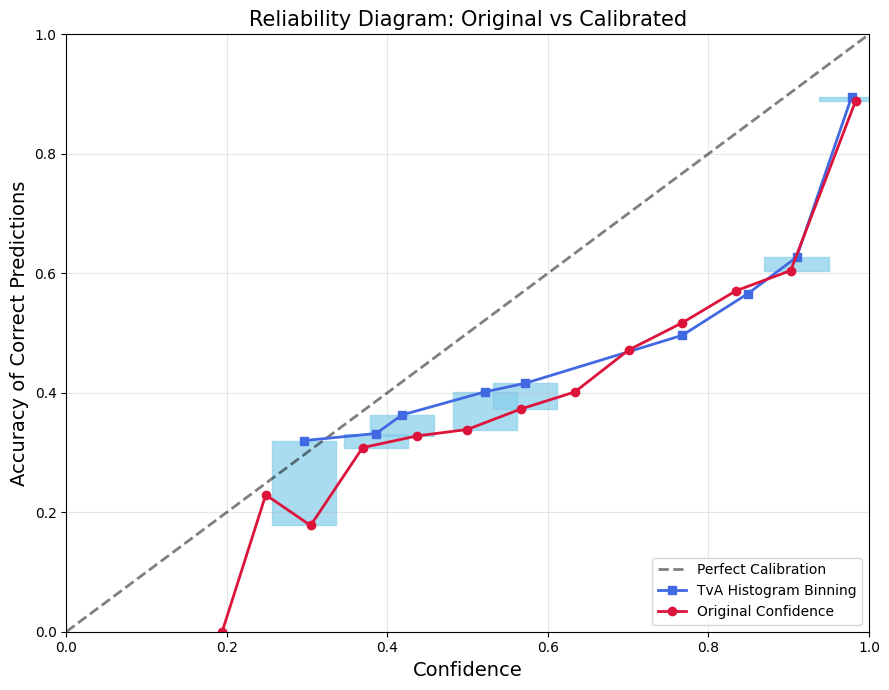

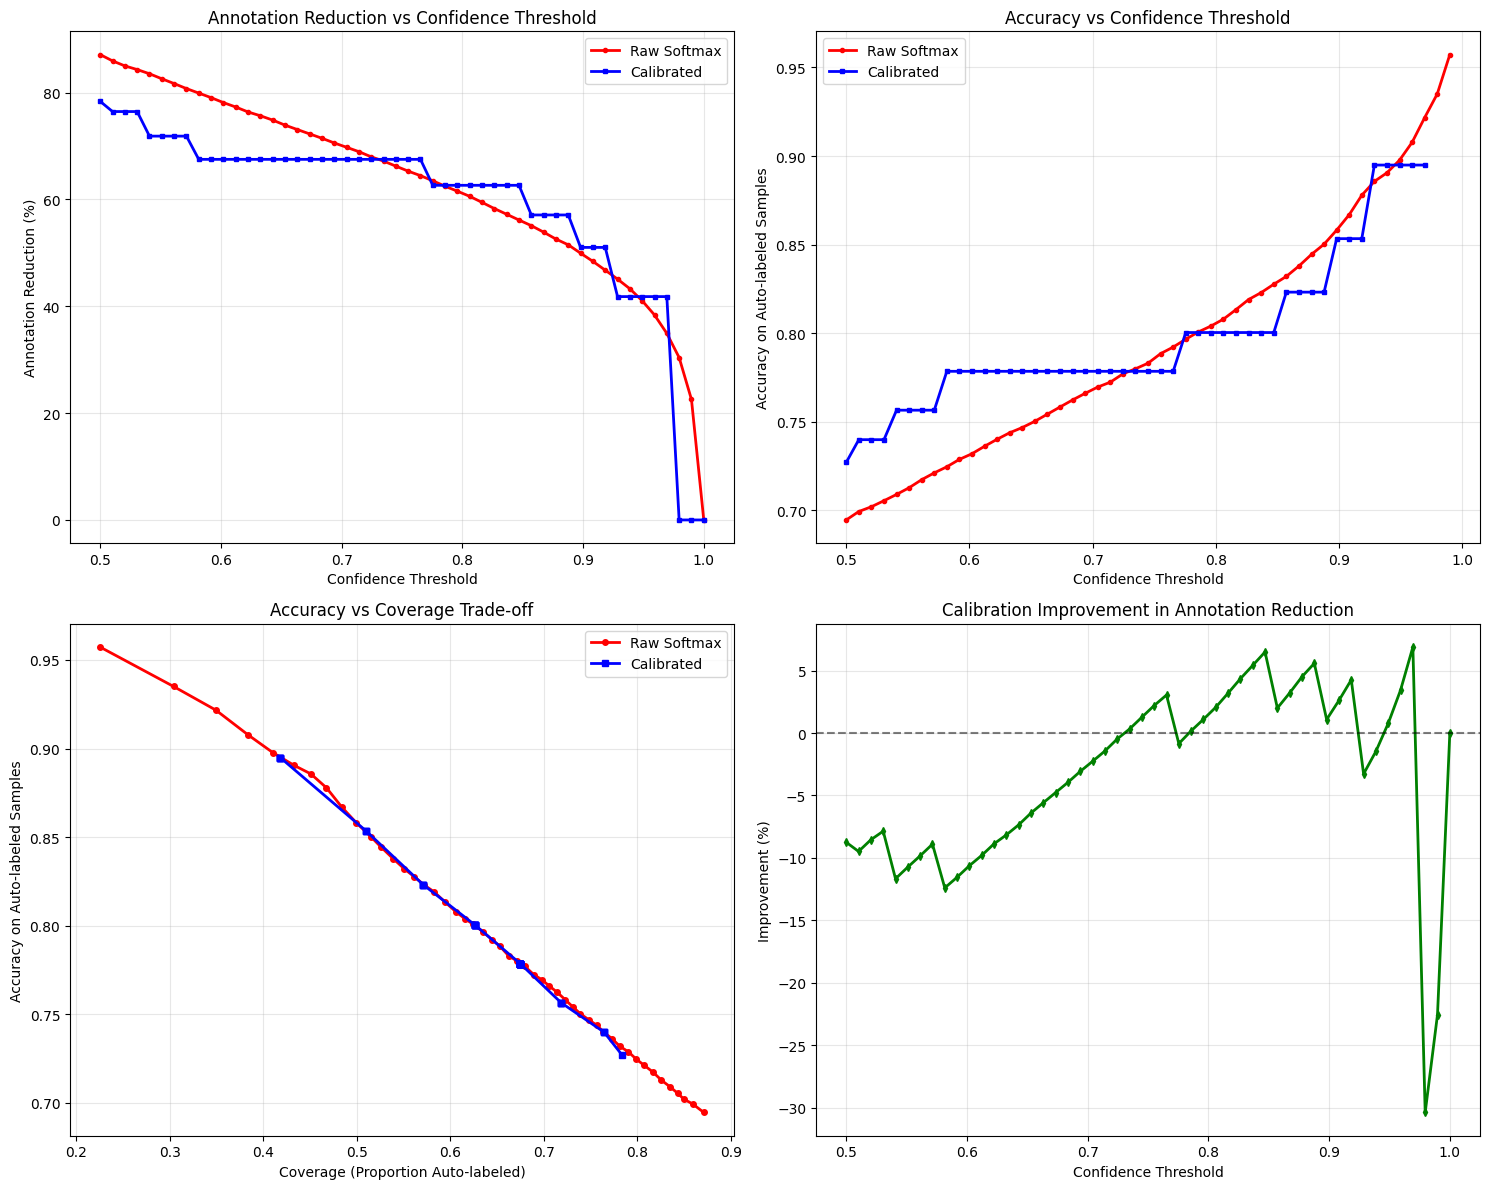

{'models': {0: ScratchResNet(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (layer1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [5]:
# Step 5: Run PretrainingPipeline Directly
pretraining_pipeline.run_pipeline()

---
# Analysis

1. Overfitting even on in-distribution benchmark validation set. Explore architecture changes in the final hidden layers prior to the classification layer.

2. Input data is highly imbalanced. Explore augmentation to reduce overfitting